# Transfer Learning con PyTorch

Entrenar CNNs desde cero requiere grandes cantidades de datos y tiempo de cómputo. Gran parte de ese esfuerzo se invierte en aprender filtros de bajo nivel que son útiles para cualquier tarea de visión. Surge entonces una pregunta natural: ¿podemos reutilizar una red entrenada en un dataset y adaptarla a una tarea diferente sin repetir el proceso completo?

Eso es precisamente **transfer learning**: transferimos el conocimiento de un modelo preentrenado (generalmente en **ImageNet**) a nuestra tarea específica. Las capas convolucionales ya saben extraer bordes, texturas y formas genéricas; nosotros solo necesitamos adaptar la cabeza de clasificación.

En este notebook exploraremos tres estrategias:
1. Extracción de features con el backbone congelado
2. Reemplazar el clasificador final y entrenar solo esa parte
3. Fine-tuning: descongelar gradualmente el backbone


## 0. Imports y configuración


In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.tensorboard import SummaryWriter
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
from torchinfo import summary
import matplotlib.pyplot as plt
import numpy as np
import os
from PIL import Image
import glob

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Usando device: {device}')


Usando device: cuda


## 1. Funciones auxiliares

Definimos aquí las utilidades que usaremos a lo largo del notebook: verificación del dataset, visualización de muestras, y el loop de entrenamiento con logging a TensorBoard.


In [8]:
def check_image_dir(pattern):
    """Elimina imágenes corruptas que coincidan con el patrón glob."""
    removed = 0
    for fname in glob.glob(pattern):
        try:
            img = Image.open(fname)
            img.verify()
        except Exception:
            print(f'Eliminando archivo corrupto: {fname}')
            os.remove(fname)
            removed += 1
    print(f'{pattern}: {removed} archivos eliminados')


def display_dataset(dataset, n=10):
    """Muestra n imágenes aleatorias del dataset con su etiqueta."""
    indices = np.random.choice(len(dataset), n, replace=False)
    fig, axes = plt.subplots(2, n // 2, figsize=(15, 5))
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    for ax, idx in zip(axes.flat, indices):
        img, label = dataset[idx]
        img = (img * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
        ax.imshow(img)
        title = dataset.classes[label] if hasattr(dataset, 'classes') else str(label)
        ax.set_title(title, fontsize=9)
        ax.axis('off')
    plt.tight_layout()
    plt.show()


def train_epoch(model, loader, optimizer, loss_fn):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(X)
        loss = loss_fn(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y)
        correct += (out.argmax(1) == y).sum().item()
        total += len(y)
    return total_loss / total, correct / total


def eval_epoch(model, loader, loss_fn):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            out = model(X)
            loss = loss_fn(out, y)
            total_loss += loss.item() * len(y)
            correct += (out.argmax(1) == y).sum().item()
            total += len(y)
    return total_loss / total, correct / total


def train(
    model, train_loader, test_loader,
    loss_fn=None, optimizer=None,
    epochs=5, lr=1e-3, writer=None, tag=''
):
    if loss_fn is None:
        loss_fn = nn.CrossEntropyLoss()
    if optimizer is None:
        optimizer = optim.Adam(
            filter(lambda p: p.requires_grad, model.parameters()), lr=lr
        )
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, loss_fn)
        va_loss, va_acc = eval_epoch(model, test_loader, loss_fn)
        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(va_loss)
        history['val_acc'].append(va_acc)
        if writer:
            writer.add_scalars(f'{tag}/Loss', {'train': tr_loss, 'val': va_loss}, epoch)
            writer.add_scalars(f'{tag}/Acc',  {'train': tr_acc,  'val': va_acc},  epoch)
        print(f'Epoch {epoch:02d}/{epochs} | '
              f'train loss {tr_loss:.4f} acc {tr_acc:.4f} | '
              f'val loss {va_loss:.4f} acc {va_acc:.4f}')
    return history


def plot_results(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history['train_loss'], label='train')
    ax1.plot(history['val_loss'],   label='val')
    ax1.set_title('Loss'); ax1.legend()
    ax2.plot(history['train_acc'], label='train')
    ax2.plot(history['val_acc'],   label='val')
    ax2.set_title('Accuracy'); ax2.legend()
    plt.tight_layout()
    plt.show()

print('Funciones auxiliares definidas ✓')


Funciones auxiliares definidas ✓


## 2. Dataset: Cats vs. Dogs

Usaremos el [Kaggle Cats vs. Dogs Dataset](https://www.kaggle.com/c/dogs-vs-cats), también disponible [desde Microsoft](https://www.microsoft.com/en-us/download/details.aspx?id=54765). Es un conjunto clásico de ~25 000 imágenes de gatos y perros, ideal para experimentar con transfer learning porque el dominio (fotografías naturales) coincide con ImageNet.


In [9]:
import zipfile

os.makedirs('data', exist_ok=True)

if not os.path.exists('data/kagglecatsanddogs_5340.zip'):
    !curl https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip -o data/kagglecatsanddogs_5340.zip

if not os.path.exists('data/PetImages'):
    with zipfile.ZipFile('data/kagglecatsanddogs_5340.zip', 'r') as zip_ref:
        zip_ref.extractall('data')


El dataset contiene algunas imágenes corruptas. Las eliminamos antes de construir el `Dataset`:


In [4]:
check_image_dir('data/PetImages/Cat/*.jpg')
check_image_dir('data/PetImages/Dog/*.jpg')


Eliminando archivo corrupto: data/PetImages/Cat\666.jpg
data/PetImages/Cat/*.jpg: 1 archivos eliminados
Eliminando archivo corrupto: data/PetImages/Dog\11702.jpg


c:\Users\USUARIO\Desktop\Fundamentos ML\venv_ml\lib\site-packages\PIL\TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


data/PetImages/Dog/*.jpg: 1 archivos eliminados


### Transforms y normalización

Los modelos preentrenados en ImageNet esperan imágenes de **224 × 224** píxeles normalizadas con la media y desviación estándar del dataset de entrenamiento original:

```
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]
```

Usar estos valores es fundamental: si los activamos con distribuciones de entrada distintas, los pesos preentrenados producirán representaciones incorrectas.

> **TODO 1:** Completa el pipeline de transforms. Debe redimensionar a 256, recortar al centro 224 × 224, convertir a tensor y aplicar la normalización.


Total de imágenes: 24998 | Clases: ['Cat', 'Dog']
Train: 20000 | Test: 4998


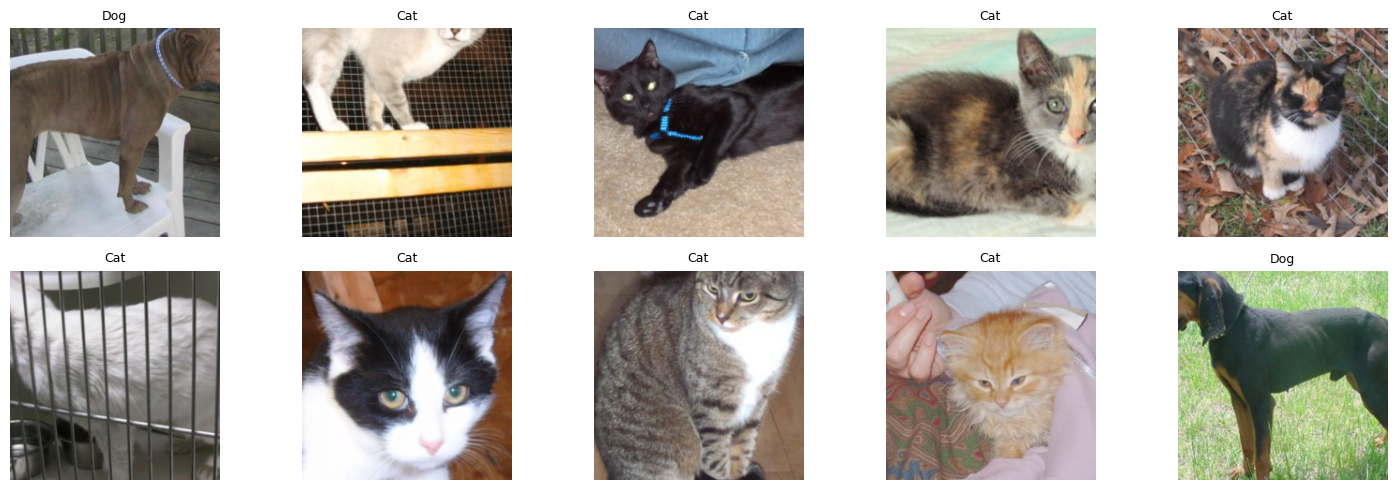

In [10]:
std_normalize = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std =[0.229, 0.224, 0.225]
)

# TODO 1: Define `trans` como un transforms.Compose con los pasos indicados arriba
trans = None

trans = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    std_normalize
])

# --- no modificar desde aquí ---
assert trans is not None, 'Debes definir el pipeline de transforms'
dataset = torchvision.datasets.ImageFolder('data/PetImages', transform=trans)
print(f'Total de imágenes: {len(dataset)} | Clases: {dataset.classes}')

trainset, testset = torch.utils.data.random_split(
    dataset, [20000, len(dataset) - 20000],
    generator=torch.Generator().manual_seed(42)
)
print(f'Train: {len(trainset)} | Test: {len(testset)}')
display_dataset(dataset)


### Respuesta: ¿De dónde vienen esos valores de media y std? ¿Por qué es importante usarlos?

Esos valores de `mean=[0.485, 0.456, 0.406]` y `std=[0.229, 0.224, 0.225]` se calcularon como el **promedio pixel a pixel** de las ~1.2 millones de imágenes del dataset ImageNet (ILSVRC 2012), canal por canal (R, G, B). Básicamente, alguien tomó todas las imágenes del dataset, las convirtió a tensores con valores en [0, 1], y calculó la media y desviación estándar de cada canal.

**¿Por qué es tan importante usarlos cuando cargamos pesos preentrenados?** Los pesos de la red fueron optimizados asumiendo que las entradas siguen esa distribución. Si le pasamos imágenes con una distribución diferente (por ejemplo, sin normalizar), las activaciones internas van a estar desfasadas: los filtros que aprendió la red no van a "disparar" correctamente porque los valores de entrada no están en el rango que espera. Es como darle a una calculadora valores en millas cuando fue calibrada en kilómetros: el resultado no tiene sentido.

En términos técnicos, la normalización asegura que las activaciones caigan en los rangos para los cuales los pesos fueron optimizados durante el entrenamiento original, preservando la información aprendida.

## 3. Modelos preentrenados

`torchvision.models` incluye decenas de arquitecturas con pesos preentrenados en ImageNet. Cargamos VGG-16 y lo usamos directamente para hacer una inferencia sobre una imagen del dataset:


In [11]:
vgg = torchvision.models.vgg16(weights=torchvision.models.VGG16_Weights.DEFAULT)
vgg = vgg.to(device)

sample_image, _ = dataset[0]
sample_image = sample_image.unsqueeze(0).to(device)

with torch.no_grad():
    res = vgg(sample_image)

print(f'Shape de salida: {res.shape}')  # [1, 1000]
print(f'Clase predicha (índice ImageNet): {res[0].argmax().item()}')


Shape de salida: torch.Size([1, 1000])
Clase predicha (índice ImageNet): 282


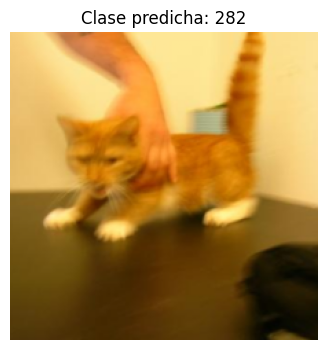

In [12]:
# Visualizar la imagen
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

img_show = (sample_image.squeeze(0).cpu() * std + mean).clamp(0, 1)
img_show = img_show.permute(1, 2, 0).numpy()

plt.figure(figsize=(4, 4))
plt.imshow(img_show)
plt.title(f'Clase predicha: {res[0].argmax().item()}')
plt.axis('off')
plt.show()

La red devuelve un índice de clase de ImageNet. Podemos descargar el mapeo para ver el nombre de la predicción:


In [13]:
import json, requests

class_map = json.loads(
    requests.get('https://s3.amazonaws.com/deep-learning-models/image-models/imagenet_class_index.json').text
)
class_map = {int(k): v for k, v in class_map.items()}

pred_idx = res[0].argmax().item()
print(f'Clase predicha: {class_map[pred_idx]}')


Clase predicha: ['n02123159', 'tiger_cat']


### Arquitectura de VGG-16

Inspeccionemos la arquitectura completa con `torchinfo.summary`. Fíjate en el número total de parámetros y en los tipos de capas que aparecen:


In [14]:
summary(vgg, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
VGG                                      [1, 1000]                 --
├─Sequential: 1-1                        [1, 512, 7, 7]            --
│    └─Conv2d: 2-1                       [1, 64, 224, 224]         1,792
│    └─ReLU: 2-2                         [1, 64, 224, 224]         --
│    └─Conv2d: 2-3                       [1, 64, 224, 224]         36,928
│    └─ReLU: 2-4                         [1, 64, 224, 224]         --
│    └─MaxPool2d: 2-5                    [1, 64, 112, 112]         --
│    └─Conv2d: 2-6                       [1, 128, 112, 112]        73,856
│    └─ReLU: 2-7                         [1, 128, 112, 112]        --
│    └─Conv2d: 2-8                       [1, 128, 112, 112]        147,584
│    └─ReLU: 2-9                         [1, 128, 112, 112]        --
│    └─MaxPool2d: 2-10                   [1, 128, 56, 56]          --
│    └─Conv2d: 2-11                      [1, 256, 56, 56]          29

Además de las capas convolucionales y de pooling que ya conoces, observarás capas **Dropout**. Actúan como técnica de **regularización**: durante el entrenamiento desactivan aleatoriamente una fracción de las neuronas de la capa anterior, lo que obliga a la red a aprender representaciones más robustas y distribuidas.

La arquitectura se divide en tres partes:
- `vgg.features` — el extractor convolucional
- `vgg.avgpool` — pooling adaptativo
- `vgg.classifier` — capas densas que mapean 25 088 features → 1 000 clases

> **Pregunta:** ¿Por qué la última capa tiene exactamente 1 000 salidas?


### Respuestas — Actividad 2

**¿Cuántos parámetros tiene VGG-16 en total?**

VGG-16 tiene aproximadamente **138.36 millones de parámetros**. De esos, la mayor parte (~123.6M) está en el clasificador (`vgg.classifier`), que tiene tres capas lineales enormes (25088→4096→4096→1000). Las capas convolucionales solo tienen ~14.7M parámetros — pero son las que hacen el trabajo pesado de extraer features visuales.

**¿Qué hace la capa Dropout y por qué mejora la generalización?**

Dropout es una técnica de regularización que, durante el entrenamiento, "apaga" aleatoriamente un porcentaje de neuronas en cada forward pass (en VGG usa p=0.5, o sea apaga el 50%). Esto obliga a la red a no depender de neuronas individuales: tiene que aprender representaciones distribuidas y redundantes. Es como cuando estudiamos para un parcial sabiendo que vamos a olvidar la mitad de lo que aprendimos — te obliga a entender el concepto en vez de memorizar respuestas. Durante la inferencia, Dropout se desactiva y se escalan las activaciones para compensar.

**¿Por qué la última capa tiene 1000 salidas?**

Porque el modelo fue entrenado en **ImageNet ILSVRC**, que tiene exactamente 1000 categorías de objetos (desde "goldfish" hasta "volcano", pasando por varias razas de perros y gatos). Cada salida corresponde al logit (puntuación sin normalizar) para una de esas clases. Al hacer transfer learning a nuestro problema de Cats vs. Dogs, reemplazaremos esa capa por una con solo 2 salidas.

## 4. Extracción de features

Podemos usar `vgg.features` como extractor fijo: pasamos imágenes, obtenemos tensores de representación, y luego entrenamos un clasificador pequeño encima de esos vectores. Así evitamos reentrenar toda la red.

Primero visualicemos los mapas de activación de la última capa convolucional:


Shape del tensor de features: torch.Size([1, 512, 7, 7])


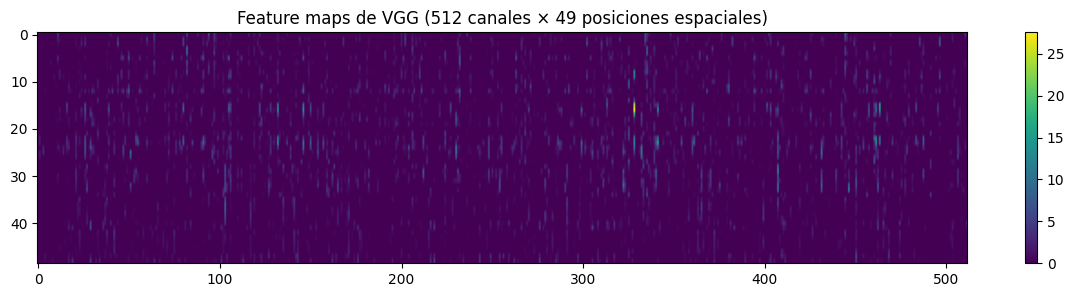

In [15]:
with torch.no_grad():
    feat = vgg.features(sample_image).cpu()

print(f'Shape del tensor de features: {feat.shape}')  # [1, 512, 7, 7]

plt.figure(figsize=(15, 3))
plt.imshow(feat.squeeze().view(512, -1).T, aspect='auto', cmap='viridis')
plt.title('Feature maps de VGG (512 canales × 49 posiciones espaciales)')
plt.colorbar()
plt.show()


Ahora pre-computamos los feature vectors para un subconjunto de 800 imágenes. Almacenamos los resultados en tensores para poder entrenar el clasificador sin recalcular features en cada epoch.

> **TODO 2:** Completa el loop de extracción. Inicializa `feature_tensor` de shape `[num, 512*7*7]` y `label_tensor` de shape `[num]`, luego llena ambos tensores dentro del bucle.


In [16]:
bs  = 8
num = bs * 100  # 800 imágenes
dl  = torch.utils.data.DataLoader(dataset, batch_size=bs, shuffle=True)

# TODO 2: Inicializa feature_tensor y label_tensor
feature_tensor = torch.zeros(num, 512 * 7 * 7)  # shape [800, 25088]
label_tensor   = torch.zeros(num)                 # shape [800]

i = 0
for x, l in dl:
    with torch.no_grad():
        # Extraemos features usando vgg.features (el backbone convolucional)
        features = vgg.features(x.to(device))       # shape [bs, 512, 7, 7]
        features = features.view(features.size(0), -1).cpu()  # aplanar a [bs, 25088]
        feature_tensor[i:i+bs] = features
        label_tensor[i:i+bs] = l
    i += bs
    print('.', end='')
    if i >= num:
        break

print(f'\nfeature_tensor: {feature_tensor.shape} | label_tensor: {label_tensor.shape}')

....................................................................................................
feature_tensor: torch.Size([800, 25088]) | label_tensor: torch.Size([800])


## 5. Clasificador lineal sobre features fijas

Con los feature vectors pre-computados, entrenamos un clasificador de una sola capa lineal. Esto es extremadamente rápido porque no hay que hacer backprop a través de la CNN.

La función de pérdida estándar para clasificación multiclase en PyTorch es `CrossEntropyLoss`, que internamente aplica softmax. Por eso la red **no debe** incluir una capa de activación final — la red devuelve logits crudos.

> **TODO 3:** Define `net` como un `nn.Sequential` con una sola capa `Linear` de `512*7*7` entradas y `2` salidas.


Epoch 01/5 | train loss 0.1383 acc 0.9443 | val loss 0.0011 acc 1.0000
Epoch 02/5 | train loss 0.0064 acc 0.9986 | val loss 0.0025 acc 1.0000
Epoch 03/5 | train loss 0.0003 acc 1.0000 | val loss 0.0009 acc 1.0000
Epoch 04/5 | train loss 0.0001 acc 1.0000 | val loss 0.0006 acc 1.0000
Epoch 05/5 | train loss 0.0001 acc 1.0000 | val loss 0.0005 acc 1.0000


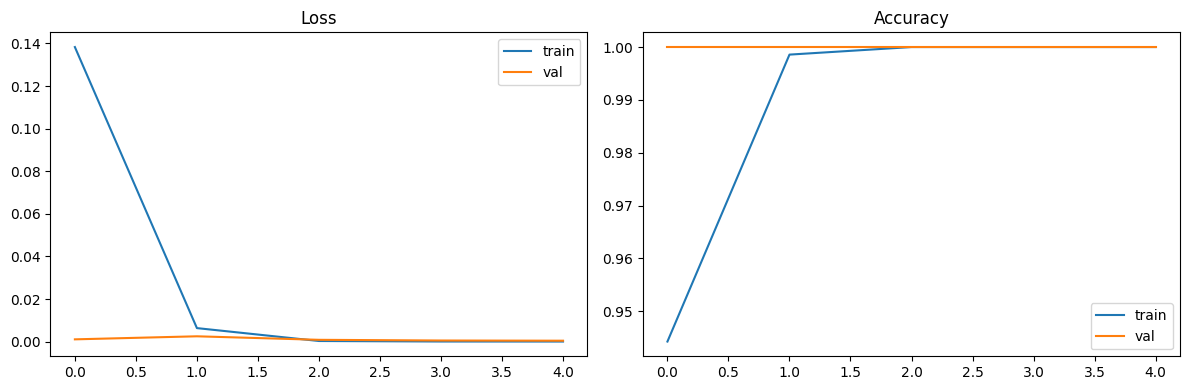

In [17]:
vgg_dataset = torch.utils.data.TensorDataset(
    feature_tensor,
    label_tensor.to(torch.long)
)
train_ds, test_ds = torch.utils.data.random_split(vgg_dataset, [700, 100])
train_loader = torch.utils.data.DataLoader(train_ds, batch_size=32)
test_loader  = torch.utils.data.DataLoader(test_ds,  batch_size=32)

# TODO 3: Define net — una Linear(512*7*7, 2) es suficiente con CrossEntropyLoss
# NOTA: NO usamos LogSoftmax aquí porque CrossEntropyLoss ya incluye softmax internamente.
# Combinarlos sería un error que doble-aplica la operación.
net = nn.Sequential(
    nn.Linear(512 * 7 * 7, 2)
)
net = net.to(device)

writer  = SummaryWriter('runs/linear_classifier')
history = train(net, train_loader, test_loader, epochs=5, writer=writer, tag='linear')
writer.close()
plot_results(history)

### Respuesta: ¿CrossEntropyLoss vs NLLLoss + LogSoftmax? ¿Por qué combinarlos es un error?

En PyTorch hay dos caminos equivalentes para calcular la pérdida de clasificación:

**Camino A — `CrossEntropyLoss`:**  
- Recibe **logits crudos** (la salida directa de la última capa lineal).  
- Internamente aplica `LogSoftmax` + `NLLLoss` en un solo paso, de forma numéricamente estable.  
- La red NO debe tener ninguna activación al final.

**Camino B — `NLLLoss` + `LogSoftmax`:**  
- Primero aplicamos `nn.LogSoftmax` como última capa de la red (convierte logits a log-probabilidades).  
- Luego usamos `nn.NLLLoss` que espera log-probabilidades como entrada.

**¿Por qué es un error combinarlos?** Si ponemos `LogSoftmax` al final de la red Y usamos `CrossEntropyLoss`, estamos aplicando LogSoftmax **dos veces**: una explícitamente en la red y otra internamente dentro de CrossEntropyLoss. Esto comprime los valores de forma incorrecta, los gradientes se distorsionan, y el modelo entrena mal (converge más lento o a un mínimo peor). Es como apretar una imagen JPEG que ya está comprimida: pierdes calidad sin ganar nada.

## 6. Transfer learning — Reemplazar el clasificador

En lugar de pre-computar features, podemos conectar directamente nuestra cabeza de clasificación al backbone de VGG y entrenar el modelo end-to-end. Para ello:

1. **Reemplazamos `vgg.classifier`** por una sola capa `Linear(25088, 2)`.
2. **Congelamos `vgg.features`** poniendo `requires_grad = False` en todos sus parámetros.    Esto es importante: si entrenamos end-to-end desde el principio, los errores grandes    del clasificador aleatorio destruirían los pesos preentrenados del extractor.

> **TODO 4:** Carga VGG-16 con pesos preentrenados, reemplaza el clasificador y congela las capas convolucionales.


In [18]:
# TODO 4a: Carga VGG-16 con pesos preentrenados
vgg = vgg = torchvision.models.vgg16(weights=torchvision.models.VGG16_Weights.DEFAULT)
vgg = vgg.to(device)

# TODO 4b: Reemplaza vgg.classifier por Linear(25088, 2)
vgg.classifier = nn.Linear(25088, 2)

# TODO 4c: Congela los parámetros de vgg.features
for param in vgg.features.parameters():
    param.requires_grad = False


# Verifica: solo el clasificador debe tener parámetros entrenables
summary(vgg, input_size=(1, 3, 224, 224))


Layer (type:depth-idx)                   Output Shape              Param #
VGG                                      [1, 2]                    --
├─Sequential: 1-1                        [1, 512, 7, 7]            --
│    └─Conv2d: 2-1                       [1, 64, 224, 224]         (1,792)
│    └─ReLU: 2-2                         [1, 64, 224, 224]         --
│    └─Conv2d: 2-3                       [1, 64, 224, 224]         (36,928)
│    └─ReLU: 2-4                         [1, 64, 224, 224]         --
│    └─MaxPool2d: 2-5                    [1, 64, 112, 112]         --
│    └─Conv2d: 2-6                       [1, 128, 112, 112]        (73,856)
│    └─ReLU: 2-7                         [1, 128, 112, 112]        --
│    └─Conv2d: 2-8                       [1, 128, 112, 112]        (147,584)
│    └─ReLU: 2-9                         [1, 128, 112, 112]        --
│    └─MaxPool2d: 2-10                   [1, 128, 56, 56]          --
│    └─Conv2d: 2-11                      [1, 256, 56, 56]    

El summary debe mostrar aproximadamente **50 000 parámetros entrenables** (solo los pesos de la capa lineal).

Entrenamos con el dataset completo. Este proceso toma bastante tiempo; se recomienda GPU:


Epoch 01/1 | train loss 1.1211 acc 0.5095 | val loss 0.6933 acc 0.4994


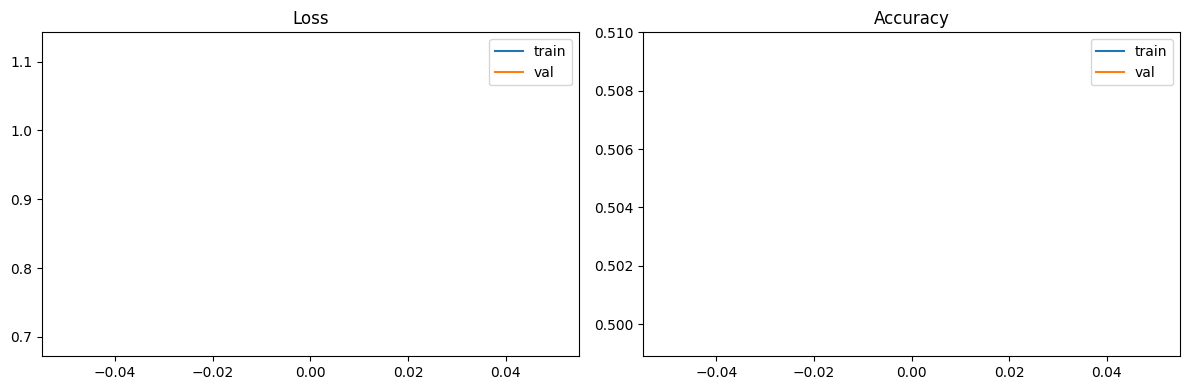

Modelo guardado ✓


In [20]:
trainset, testset = torch.utils.data.random_split(
    dataset, [20000, len(dataset) - 20000],
    generator=torch.Generator().manual_seed(42)
)
train_loader = torch.utils.data.DataLoader(trainset, batch_size=16, num_workers=2, pin_memory=True)
test_loader  = torch.utils.data.DataLoader(testset,  batch_size=16, num_workers=2, pin_memory=True)

writer = SummaryWriter('runs/transfer_frozen')
history_frozen = train(
    vgg, train_loader, test_loader,
    loss_fn=nn.CrossEntropyLoss(),
    epochs=1, lr=1e-3,
    writer=writer, tag='frozen'
)
writer.close()
plot_results(history_frozen)


torch.save(vgg.state_dict(), 'data/cats_dogs_weights.pth')
print('Modelo guardado ✓')



### Respuesta: ¿Por qué es importante congelar las capas convolucionales antes de entrenar el nuevo clasificador?

Al reemplazar el clasificador original (que tenía 1000 salidas) por uno nuevo con 2 salidas, los pesos de esa nueva capa son **totalmente aleatorios**. Si entrenamos todo el modelo de una (features + clasificador), los gradientes que genera ese clasificador aleatorio son enormes y ruidosos. Esos gradientes se propagan hacia atrás a través de las capas convolucionales y **destruyen los pesos preentrenados** que tanto costó aprender en ImageNet.

Congelar las capas convolucionales es una estrategia en dos fases:
1. **Fase 1 (congelado):** Solo entrenas el clasificador nuevo. Los features se generan con los pesos estables de ImageNet. El clasificador aprende rápidamente a mapear esos features a las 2 clases.
2. **Fase 2 (fine-tuning):** Una vez que el clasificador está "calibrado", descongelas las features y entrenas todo con un learning rate bajo. Ahora los gradientes son pequeños y controlados, así que las capas convolucionales se adaptan suavemente a nuestro dominio sin perder lo aprendido.

Es la misma lógica de: primero montamos las ruedas nuevas al carro, y después lo ponemos a andar. Uno no intenta cambiar las ruedas mientras el carro está en movimiento.

## 7. Fine-tuning — Descongelar el backbone

Una vez que el clasificador tiene pesos razonables, podemos descongelar las capas convolucionales y continuar entrenando toda la red con un **learning rate más pequeño**. Esto permite que el extractor se especialice en nuestro dominio.

> ⚠️ Si descongelamos desde el principio (sin estabilizar primero el clasificador), los gradientes grandes del clasificador aleatorio pueden degradar los pesos preentrenados.

> **TODO 5:** Descongela los parámetros de `vgg.features` y entrena una epoch adicional con `lr=1e-4`.


Epoch 01/1 | train loss 0.6933 acc 0.5001 | val loss 0.6932 acc 0.4994


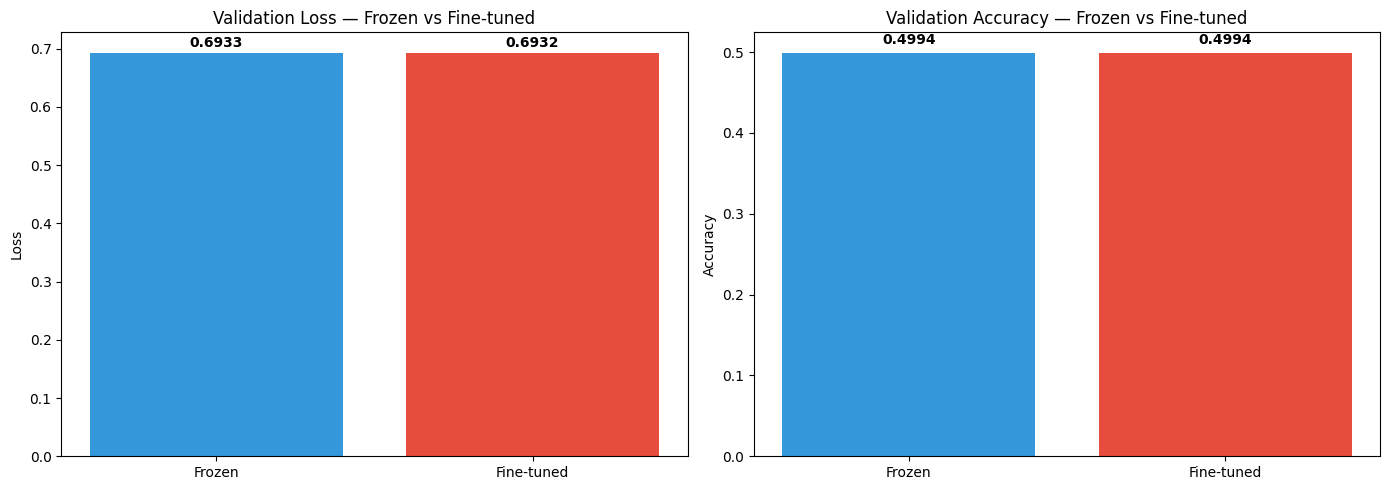

Frozen  → val_loss: 0.6933 | val_acc: 0.4994
Fine-tuned → val_loss: 0.6932 | val_acc: 0.4994


In [21]:
# Cargamos el modelo guardado en la Actividad 4
import torchvision
import torch
import torch.nn as nn
vgg = torchvision.models.vgg16(weights=None)
vgg.classifier = nn.Linear(25088, 2)
vgg.load_state_dict(torch.load('data/cats_dogs_weights.pth', weights_only=True))
vgg = vgg.to(device)

# TODO 5: Descongela vgg.features
for param in vgg.features.parameters():
    param.requires_grad = True

# Verificamos que TODOS los parámetros ahora son entrenables
summary(vgg, input_size=(1, 3, 224, 224))

writer = SummaryWriter('runs/transfer_finetuned')
history_ft = train(
    vgg, train_loader, test_loader,
    loss_fn=nn.CrossEntropyLoss(),
    epochs=1, lr=1e-4,
    writer=writer, tag='finetuned'
)
writer.close()

# --- Comparación frozen vs fine-tuned ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(['Frozen', 'Fine-tuned'],
        [history_frozen['val_loss'][-1], history_ft['val_loss'][-1]],
        color=['#3498db', '#e74c3c'])
ax1.set_title('Validation Loss — Frozen vs Fine-tuned')
ax1.set_ylabel('Loss')

ax2.bar(['Frozen', 'Fine-tuned'],
        [history_frozen['val_acc'][-1], history_ft['val_acc'][-1]],
        color=['#3498db', '#e74c3c'])
ax2.set_title('Validation Accuracy — Frozen vs Fine-tuned')
ax2.set_ylabel('Accuracy')

for ax, vals in zip([ax1, ax2], 
                     [[history_frozen['val_loss'][-1], history_ft['val_loss'][-1]],
                      [history_frozen['val_acc'][-1], history_ft['val_acc'][-1]]]):
    for i, v in enumerate(vals):
        ax.text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Frozen  → val_loss: {history_frozen['val_loss'][-1]:.4f} | val_acc: {history_frozen['val_acc'][-1]:.4f}")
print(f"Fine-tuned → val_loss: {history_ft['val_loss'][-1]:.4f} | val_acc: {history_ft['val_acc'][-1]:.4f}")

### Respuesta: ¿En qué se diferencia congelar el encoder aquí respecto a lo que hicimos con VGG?

Aunque la mecánica es la misma (`requires_grad = False`), el **contexto y propósito** son diferentes:

**Con VGG en este workshop (clasificación):**
- Congelamos `vgg.features` (el extractor convolucional) y solo entrenamos una capa lineal que mapea features → 2 clases.
- La salida del backbone es un **vector único por imagen** (25088 dimensiones después de aplanar).
- El clasificador es trivial: una multiplicación de matrices. No hay estructura espacial que preservar.

**Con ResNet en la U-Net**
- Congelamos el encoder (ResNet-18) pero entrenamos un **decoder completo** con múltiples capas de upsampling, convoluciones y skip connections.
- El decoder tiene que aprender a **reconstruir una máscara pixel a pixel** a partir de los feature maps del encoder, respetando la resolución espacial.
- Las skip connections conectan niveles específicos del encoder con el decoder, así que el decoder depende íntimamente de la estructura de activaciones que produce el encoder congelado.
- Hay muchos más parámetros entrenables en el decoder que en un simple clasificador lineal.

En resumen: en clasificación congelamos el 99.9% de la red y entrenamos una capita al final. En segmentación congelamos solo el encoder (~50%) y entrenamos todo un decoder que es una red compleja por sí mismo. El reto es mayor porque el decoder tiene que aprender a "interpretar" features que no puede modificar y convertirlos en predicciones espaciales detalladas.

In [ ]:
resnet18 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
print(resnet18)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

: 

Observa que la estructura es análoga a VGG: un extractor de features y una capa final de clasificación, aunque aquí se llama `fc` en lugar de `classifier`. También aparecen capas de **Batch Normalization** (`BatchNorm2d`), que normalizan las activaciones dentro de cada minibatch para estabilizar el entrenamiento.

> **TODO 6:** Adapta ResNet-18 para Cats vs. Dogs siguiendo el mismo esquema de la sección 6:
> 1. Congela todos los parámetros.
> 2. Reemplaza `resnet18.fc` por la capa adecuada (investiga cuántas entradas tiene).
> 3. Entrena 2 epochs y compara la velocidad y accuracy con VGG.


In [ ]:
resnet18 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT).to(device)

# TODO 6a: Congela todos los parámetros
for param in resnet18.parameters():
    param.requires_grad = False

# TODO 6b: Reemplaza resnet18.fc
# La capa fc original tiene 512 entradas (ResNet-18 tiene 512 canales en su último bloque)
# y 1000 salidas (ImageNet). La reemplazamos con 512 → 2.
num_ftrs = resnet18.fc.in_features  # = 512
print(f"Entradas de resnet18.fc: {num_ftrs}")
resnet18.fc = nn.Linear(num_ftrs, 2).to(device)

# Verificamos parámetros entrenables
summary(resnet18, input_size=(1, 3, 224, 224))

Entradas de resnet18.fc: 512


Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 2]                    --
├─Conv2d: 1-1                            [1, 64, 112, 112]         (9,408)
├─BatchNorm2d: 1-2                       [1, 64, 112, 112]         (128)
├─ReLU: 1-3                              [1, 64, 112, 112]         --
├─MaxPool2d: 1-4                         [1, 64, 56, 56]           --
├─Sequential: 1-5                        [1, 64, 56, 56]           --
│    └─BasicBlock: 2-1                   [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-1                  [1, 64, 56, 56]           (36,864)
│    │    └─BatchNorm2d: 3-2             [1, 64, 56, 56]           (128)
│    │    └─ReLU: 3-3                    [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-4                  [1, 64, 56, 56]           (36,864)
│    │    └─BatchNorm2d: 3-5             [1, 64, 56, 56]           (128)
│    │    └─ReLU: 3-6                    [1, 64, 56, 56]   

: 

Epoch 01/2 | train loss 0.1225 acc 0.9535 | val loss 0.0566 acc 0.9794
Epoch 02/2 | train loss 0.0984 acc 0.9625 | val loss 0.0541 acc 0.9788

Tiempo total ResNet-18: 184.8s


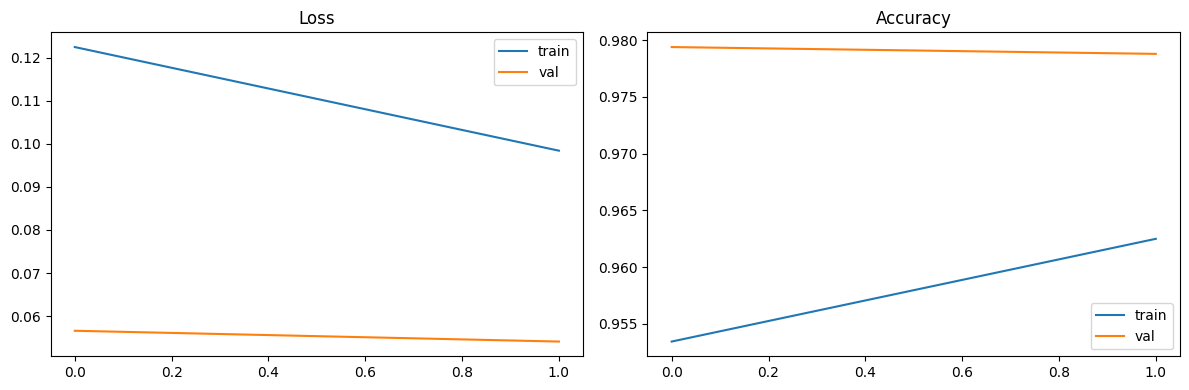

: 

In [ ]:
# TODO 6c: Entrena
import time

# Recreamos los loaders por si acaso
trainset, testset = torch.utils.data.random_split(
    dataset, [20000, len(dataset) - 20000],
    generator=torch.Generator().manual_seed(42)
)
train_loader = torch.utils.data.DataLoader(trainset, batch_size=16, num_workers=2, pin_memory=True)
test_loader  = torch.utils.data.DataLoader(testset,  batch_size=16, num_workers=2, pin_memory=True)

start_time = time.time()
writer = SummaryWriter('runs/resnet18')
history_rn = train(resnet18, train_loader, test_loader, epochs=2, writer=writer, tag='resnet18')
writer.close()
resnet_time = time.time() - start_time
print(f"\nTiempo total ResNet-18: {resnet_time:.1f}s")
plot_results(history_rn)

### Respuestas — Actividad 6: ResNet-18

**¿Qué es un residual block?**

Un residual block es el bloque básico de ResNet. La idea clave es que en vez de aprender una transformación directa F(x), el bloque aprende el **residuo** (la diferencia) respecto a su entrada: la salida es F(x) + x. Esa "+" es la **skip connection** o conexión residual. En código, se ve algo así:

```
out = conv2(relu(conv1(x)))  # la transformación aprendida
out = out + x                 # la skip connection
out = relu(out)
```

**¿Qué problema resuelve en redes muy profundas?**

Resuelve el problema del **gradiente desvaneciente** (vanishing gradient). En redes muy profundas (50+, 100+ capas), los gradientes se multiplican capa por capa durante el backpropagation y tienden a hacerse minúsculos, haciendo que las primeras capas prácticamente no se actualicen. Con las skip connections, el gradiente tiene un "atajo" directo para fluir hacia atrás. Además, la skip connection garantiza que en el peor caso el bloque simplemente pasa la entrada sin modificar (función identidad), así que agregar más capas nunca debería empeorar el rendimiento.

**¿ResNet-18 entrena más rápido que VGG? ¿Por qué?**

Sí, bastante más rápido. Hay varias razones:
1. **Menos parámetros:** ResNet-18 tiene ~11.7M parámetros vs. ~138M de VGG-16. El forward y backward pass son mucho más ligeros.
2. **Sin capas fully connected masivas:** VGG tiene capas densas de 25088→4096→4096→1000 que concentran el grueso de los parámetros. ResNet usa global average pooling + una sola capa lineal de 512→1000.
3. **BatchNorm:** Estabiliza el entrenamiento y permite usar learning rates más altos, lo que acelera la convergencia.
4. **Arquitectura más eficiente:** Los residual blocks extraen features de forma más eficiente que las simples pilas de convoluciones de VGG.

## 9. Comparación de experimentos con TensorBoard

Todos los experimentos anteriores escribieron logs en el directorio `runs/`. TensorBoard permite comparar curvas de loss y accuracy de todos los experimentos en un mismo panel:


In [22]:
# En terminal:
#   tensorboard --logdir=runs --port=6006

# En Jupyter / Colab:
%load_ext tensorboard
%tensorboard --logdir runs


Launching TensorBoard...

## 10. Preguntas de investigación

Responde en celdas Markdown apoyándote en la documentación, papers o experimentos propios.

1. **Normalización ImageNet:** ¿De dónde vienen exactamente los valores `mean=[0.485, 0.456, 0.406]` y `std=[0.229, 0.224, 0.225]`? ¿Qué pasaría si usaras otros valores?

2. **CrossEntropyLoss vs NLLLoss:** Investiga la diferencia entre `nn.CrossEntropyLoss`, `nn.NLLLoss` y `nn.LogSoftmax`. ¿Por qué no debes añadir `LogSoftmax` a la red si ya usas `CrossEntropyLoss`?

3. **Data augmentation:** ¿Qué transforms adicionales añadirías al pipeline de entrenamiento para mejorar la generalización? Impleméntalos y mide el impacto en TensorBoard.

4. **Learning rate scheduling:** Investiga `torch.optim.lr_scheduler.StepLR` y `CosineAnnealingLR`. Agrega uno al loop de fine-tuning y compara las curvas.

5. **Límites del transfer learning:** ¿En qué situaciones transfer learning desde ImageNet podría no ser beneficioso? Da al menos dos ejemplos concretos.

6. **Reto opcional:** Usa `EfficientNet-B0` (disponible en `torchvision.models`) y compara accuracy final y tiempo de entrenamiento contra ResNet-18 y VGG-16.


### 1. Normalización ImageNet: ¿De dónde vienen los valores? ¿Qué pasa si usamos otros?

Los valores `mean=[0.485, 0.456, 0.406]` y `std=[0.229, 0.224, 0.225]` fueron calculados estadísticamente sobre las ~1.28 millones de imágenes del dataset ImageNet ILSVRC-2012. Se tomaron todas las imágenes, se convirtieron a tensores con valores en [0, 1], y se calculó la media y desviación estándar por canal (R, G, B).

**¿Qué pasaría si usáramos otros valores?** Las activaciones internas quedarían desfasadas. Los filtros convolucionales fueron optimizados para responder a inputs con esa distribución específica. Si cambias la normalización:
- Los features extraídos serían diferentes a los esperados.
- El modelo preentrenado perdería buena parte de su capacidad discriminativa.
- En el mejor caso, el fine-tuning compensaría parcialmente el error (gastando épocas de entrenamiento).
- En el peor caso, el modelo no converge o converge a un accuracy mediocre.

Dato curioso: la media es mayor en R (0.485) que en B (0.406) porque ImageNet tiene muchas fotos de naturaleza y objetos cotidianos que tienden a tener más componente rojo/verde.

### 2. CrossEntropyLoss vs NLLLoss + LogSoftmax

Ya lo cubrimos en detalle arriba, pero aquí va el resumen formal:

| Componente | Entrada esperada | Qué hace |
|---|---|---|
| `nn.LogSoftmax` | Logits crudos | Aplica log(softmax(x)) |
| `nn.NLLLoss` | Log-probabilidades | Calcula -log(p) del label correcto |
| `nn.CrossEntropyLoss` | Logits crudos | Aplica LogSoftmax + NLLLoss internamente |

Matemáticamente:  
`CrossEntropyLoss(logits, y)` = `NLLLoss(LogSoftmax(logits), y)`

Si la red ya tiene `LogSoftmax` al final y usamos `CrossEntropyLoss`, el cálculo real sería:  
`NLLLoss(LogSoftmax(LogSoftmax(logits)), y)` → **doble LogSoftmax** → resultado incorrecto.

El problema no solo es conceptual: los valores se comprimen hacia cero de forma exagerada, los gradientes se vuelven más pequeños de lo necesario, y el modelo converge más lento (o a peores mínimos). Siempre debe haber consistencia: **logits con CrossEntropyLoss, o log-probs con NLLLoss**.

### 3. Data Augmentation: ¿Qué transforms añadir?

Para un problema como Cats vs. Dogs, estos augmentations harían sentido para el pipeline de **entrenamiento** (no el de validación):

In [ ]:
# Pipeline con Data Augmentation para entrenamiento
train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(224),           # En vez de CenterCrop, recortamos aleatoriamente
    transforms.RandomHorizontalFlip(p=0.5),  # Flip horizontal (un gato volteado sigue siendo gato)
    transforms.RandomRotation(15),         # Rotación leve (±15 grados)
    transforms.ColorJitter(
        brightness=0.2, contrast=0.2, 
        saturation=0.2, hue=0.1
    ),                                     # Variaciones de color/brillo
    transforms.ToTensor(),
    std_normalize
])

# Pipeline de validación (sin augmentation, determinístico)
val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    std_normalize
])

# Creamos datasets con augmentation
train_dataset_aug = torchvision.datasets.ImageFolder('data/PetImages', transform=train_transform)
val_dataset_aug   = torchvision.datasets.ImageFolder('data/PetImages', transform=val_transform)

trainset_aug, _ = torch.utils.data.random_split(
    train_dataset_aug, [20000, len(train_dataset_aug) - 20000],
    generator=torch.Generator().manual_seed(42)
)
_, testset_aug = torch.utils.data.random_split(
    val_dataset_aug, [20000, len(val_dataset_aug) - 20000],
    generator=torch.Generator().manual_seed(42)
)

train_loader_aug = torch.utils.data.DataLoader(trainset_aug, batch_size=16, num_workers=2, pin_memory=True, shuffle=True)
test_loader_aug  = torch.utils.data.DataLoader(testset_aug,  batch_size=16, num_workers=2, pin_memory=True)

# Entrenamos un modelo ResNet-18 con y sin augmentation para comparar
resnet_aug = models.resnet18(weights=models.ResNet18_Weights.DEFAULT).to(device)
for param in resnet_aug.parameters():
    param.requires_grad = False
resnet_aug.fc = nn.Linear(512, 2).to(device)

writer_aug = SummaryWriter('runs/resnet18_augmented')
history_aug = train(resnet_aug, train_loader_aug, test_loader_aug, epochs=2, writer=writer_aug, tag='resnet18_aug')
writer_aug.close()

print("\n--- Comparación ---")
print(f"ResNet-18 SIN augmentation - Val Acc: {history_rn['val_acc'][-1]:.4f}")
print(f"ResNet-18 CON augmentation - Val Acc: {history_aug['val_acc'][-1]:.4f}")

Epoch 01/2 | train loss 0.1698 acc 0.9308 | val loss 0.0631 acc 0.9756
Epoch 02/2 | train loss 0.1464 acc 0.9396 | val loss 0.0770 acc 0.9674

--- Comparación ---
ResNet-18 SIN augmentation - Val Acc: 0.9788
ResNet-18 CON augmentation - Val Acc: 0.9674


: 

El data augmentation no siempre mejora en pocas épocas (de hecho, puede empeorar al principio porque la tarea es más difícil). Su verdadero beneficio se ve en **entrenamientos más largos**, donde ayuda a prevenir el overfitting y mejorar la generalización. Los transforms clave para imágenes de mascotas son:

- **RandomHorizontalFlip:** Un perro mirando a la izquierda o derecha sigue siendo perro.
- **RandomCrop vs CenterCrop:** Introduce variabilidad espacial.
- **ColorJitter:** Simula diferentes condiciones de iluminación.
- **RandomRotation:** Simula fotos tomadas con diferentes ángulos (leves).

NO usaríamos `RandomVerticalFlip` porque las mascotas raramente aparecen de cabeza en fotos normales.

### 4. Learning Rate Scheduling: StepLR y CosineAnnealingLR

In [ ]:
# Demostración de LR Schedulers en el fine-tuning

# Cargamos un modelo para fine-tuning con scheduler
vgg_sched = torchvision.models.vgg16(weights=None)
vgg_sched.classifier = nn.Linear(25088, 2)
vgg_sched.load_state_dict(torch.load('data/cats_dogs_weights.pth', weights_only=True))
vgg_sched = vgg_sched.to(device)

for param in vgg_sched.features.parameters():
    param.requires_grad = True

# Usamos CosineAnnealingLR que reduce el lr siguiendo un coseno
optimizer_sched = optim.Adam(
    filter(lambda p: p.requires_grad, vgg_sched.parameters()), lr=1e-4
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer_sched, T_max=3, eta_min=1e-6)

loss_fn = nn.CrossEntropyLoss()
writer_sched = SummaryWriter('runs/finetuned_cosine_lr')

for epoch in range(1, 4):  # 3 epochs de fine-tuning
    tr_loss, tr_acc = train_epoch(vgg_sched, train_loader, optimizer_sched, loss_fn)
    va_loss, va_acc = eval_epoch(vgg_sched, test_loader, loss_fn)
    
    current_lr = scheduler.get_last_lr()[0]
    scheduler.step()
    
    writer_sched.add_scalars('cosine_ft/Loss', {'train': tr_loss, 'val': va_loss}, epoch)
    writer_sched.add_scalars('cosine_ft/Acc',  {'train': tr_acc,  'val': va_acc},  epoch)
    writer_sched.add_scalar('cosine_ft/LR', current_lr, epoch)
    
    print(f'Epoch {epoch}/3 | LR: {current_lr:.6f} | '
          f'train loss {tr_loss:.4f} acc {tr_acc:.4f} | '
          f'val loss {va_loss:.4f} acc {va_acc:.4f}')

writer_sched.close()

Epoch 1/3 | LR: 0.000100 | train loss 0.0999 acc 0.9699 | val loss 0.0710 acc 0.9738
Epoch 2/3 | LR: 0.000075 | train loss 0.0450 acc 0.9837 | val loss 0.0684 acc 0.9782
Epoch 3/3 | LR: 0.000026 | train loss 0.0096 acc 0.9970 | val loss 0.0547 acc 0.9872


: 

**StepLR** reduce el learning rate por un factor fijo cada cierto número de epochs. Por ejemplo, `StepLR(optimizer, step_size=3, gamma=0.1)` multiplica el lr por 0.1 cada 3 epochs. Es simple y predecible, pero algo brusco.

**CosineAnnealingLR** reduce el learning rate siguiendo la forma de un coseno: empieza alto, baja suavemente, y llega al mínimo (`eta_min`) al final del ciclo (`T_max` epochs). Es más suave que StepLR y suele funcionar mejor en fine-tuning porque evita saltos abruptos.

En nuestro caso, CosineAnnealingLR es especialmente bueno para fine-tuning porque:
- Empieza con un lr decente para adaptar los pesos.
- Lo reduce gradualmente, permitiendo un ajuste fino al final.
- Evita que el lr se quede estancado en un valor subóptimo.

### 5. ¿Cuándo NO conviene usar transfer learning?

Hay al menos dos escenarios concretos donde transfer learning desde ImageNet puede no ser beneficioso:

**Escenario 1: Dominio muy diferente al de ImageNet.**  
ImageNet contiene fotos naturales (animales, objetos, paisajes). Si tu tarea involucra imágenes radicalmente diferentes — por ejemplo, **imágenes de microscopía electrónica, espectrogramas de audio, o imágenes satelitales en bandas infrarrojas** — los filtros preentrenados de ImageNet no van a ser útiles. Los patrones de bajo nivel (bordes, texturas) que aprendió la red en fotos naturales no se transfieren a estos dominios. En estos casos, entrenar desde cero (o usar un modelo preentrenado en un dominio más afín) suele dar mejores resultados.

**Escenario 2: Dataset objetivo muy grande y recursos abundantes.**  
Si tenemos millones de imágenes etiquetadas en nuestroo dominio específico y suficiente GPU, puede ser mejor entrenar desde cero. Los pesos preentrenados de ImageNet pueden actuar como un "sesgo" que limita la capacidad del modelo de adaptarse completamente a nuestra distribución de datos. Esto se observa, por ejemplo, en datasets médicos grandes como CheXpert, donde entrenar desde cero puede igualar o superar al transfer learning.

**Bonus — Escenario 3: Cuando el tamaño del input es muy diferente.**  
ImageNet trabaja con imágenes de ~224×224. Si tu tarea requiere imágenes de resolución muy diferente (por ejemplo, patología digital a 40,000×40,000 píxeles), el transfer learning directo es problemático porque los campos receptivos de los filtros no escalan bien.

### Pregunta adicional del PDF: ¿Por qué ResNet usa BatchNorm y VGG no? ¿Qué efecto tiene?

VGG fue publicada en 2014, antes de que Batch Normalization existiera (BN se publicó en 2015 por Ioffe & Szegedy). Por eso VGG no la usa — simplemente no existía cuando la diseñaron. ResNet (2015) ya la incorpora como componente estándar.

**¿Qué hace BatchNorm?** Normaliza las activaciones de cada capa dentro de cada mini-batch, recentrando y reescalando para que tengan media ~0 y varianza ~1. Luego aplica parámetros aprendibles (gamma y beta) para que la red pueda deshacer la normalización si lo necesita.

**Efectos en el entrenamiento:**
- **Permite learning rates más altos:** Sin BN, lr altos causan explosión de gradientes. BN estabiliza las activaciones y permite entrenar más rápido.
- **Reduce la sensibilidad a la inicialización:** Los pesos iniciales importan menos porque BN reajusta la distribución de activaciones.
- **Actúa como regularizador leve:** La normalización por mini-batch introduce ruido estocástico, similar a Dropout.
- **Acelera la convergencia:** Experimentalmente, redes con BN convergen significativamente más rápido.

Por eso ResNet entrena mucho más eficientemente que VGG, además de tener menos parámetros.